# P6 — Backtest Evaluation

The evaluation capstone of the platform notebook suite. Five things on one page,
in the order an operator should read them:

1. **Equity curves** for all five legs — the regime strategy, the no-regime
   ablation, and the three-leg baseline gauntlet (SPY buy-and-hold, 60/40, Faber's
   10-month SMA).
2. **The baseline gauntlet's KPIs**, each one checked against its plausibility band
   *before* anything is drawn.
3. **The ablation delta** — design §8.7's "does the regime layer pay rent".
4. **Calibration** at a glance, from the same persisted artifact P4 details.
5. **The §5.4 sojourn / detection-lag headline**, with its resolved-transition
   count and the mandatory audit-item-A13 caveat.

This notebook **reads**. It never fits, sweeps, tunes, or re-runs the 588-refit
walk-forward: every strategy and ablation number comes from a persisted parquet
artifact, and only the three deterministic, no-tunable-parameter price baselines
are recomputed in-notebook. It carries no sign-off cell and no per-run gate —
that responsibility belongs to P3 alone (D-15).

**Prerequisites — run these first if the artifacts below are missing:**

- `python scripts/build_platform_data.py` — builds the `monthly_raw` platform
  checkpoint (dev) and its full-span twin.
- `python -m trading_crab_lib.platform.evaluation.report` — writes all nine
  artifacts under `outputs/reports/platform/` that this notebook loads. It is
  minutes of walk-forward work and belongs on a terminal, **never** inside a
  notebook cell.

In [1]:
%matplotlib inline
import logging

import numpy as np

logging.basicConfig(level=logging.INFO)

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import drift as pdrift
from trading_crab_lib.platform.plotting import backtest as pbacktest
from trading_crab_lib.platform.evaluation.sojourn_lag import compute_sojourn_lag_headline
from trading_crab_lib.platform.honesty.holdout import DEFAULT_HOLDOUT_CUTOFF
from trading_crab_lib.platform.splice import build_core_research_series

REPORT_HINT = "python -m trading_crab_lib.platform.evaluation.report"
DATA_HINT = "python scripts/build_platform_data.py"

cfg = load_platform_config()
# Never display cfg directly (T-06-01) — it carries a live FRED_API_KEY.
print("platform config sections:", sorted(pplot.redacted_config(cfg).keys()))
print("holdout cutoff:", DEFAULT_HOLDOUT_CUTOFF)

platform config sections: ['allocation', 'backtest', 'cv', 'data', 'fred_daily', 'fred_monthly', 'fred_vintage', 'holdout', 'labeling', 'macrotrends_monthly', 'multpl_monthly', 'paid_providers', 'registry', 'report', 'splice', 'taxonomy', 'tiingo', 'tripwire', 'universe']
holdout cutoff: 2020-12-31


## The five legs, and where each one comes from

| leg | source | why |
|---|---|---|
| **strategy** | `backtest_equity_curve_strategy.parquet` | the regime-tilted book; a fitted, walk-forward model path |
| **no_regime_ablation** | `backtest_equity_curve_ablation.parquet` | the SAME L1–L4 code path with the regime tilt disabled (design §8.7) |
| **spy_buy_hold** | recomputed here | a single cost-free purchase of the spliced equity total-return series |
| **sixty_forty** | recomputed here | fixed 60/40, reconstituted monthly, costed at the config's `cost_bps` |
| **faber_sma** | recomputed here | Meb Faber's 10-month SMA rule with a strict 1-step decision lag |

The split is deliberate. The two ML legs are the expensive, fitted, registry-logged
part of the system — they are **loaded verbatim** from what the honest evaluation
run produced. The three baselines are deterministic price arithmetic with no
tunable parameter; `backtest/baselines.py`'s own documented scope says they log no
registry trial at all, which is exactly why they are safe and cheap to re-derive in
a viewing notebook.

`pbacktest.recompute_baseline_curves` mirrors the report layer's own baseline
construction using only public functions and the same `cfg["backtest"]` cost and
rebalance conventions, then bounds every leg at the holdout cutoff. Its terminal
log wealth is compared to the persisted KPI table further down — if the two ever
disagree, the re-derivation has drifted from what the KPI table summarizes and the
chart below is lying.

In [2]:
strategy_curve = pplot.load_report_artifact(
    "backtest_equity_curve_strategy.parquet", rebuild_hint=REPORT_HINT
)
ablation_curve = pplot.load_report_artifact(
    "backtest_equity_curve_ablation.parquet", rebuild_hint=REPORT_HINT
)
monthly_raw = pplot.load_platform_checkpoint("monthly_raw", rebuild_hint=DATA_HINT)

baseline_curves = pbacktest.recompute_baseline_curves(monthly_raw, cfg)

curves = {
    "strategy": strategy_curve["return"],
    "no_regime_ablation": ablation_curve["return"],
    **baseline_curves,
}

print(f"{'leg':<20} {'months':>7}  span")
for name, series in curves.items():
    clean = series.dropna()
    print(f"{name:<20} {len(clean):>7}  {clean.index.min().date()} -> {clean.index.max().date()}")

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved price_col -> 'sp500' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved div_yield_col -> 'div_yield' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'long_duration_tr': resolved yield_col -> 'fred_gs10' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'gold': resolved source_col -> 'gold_spot' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'oil': resolved source_col -> 'wti_crude' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'cash': resolved yield_col -> 'fred_tb3ms' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:Built 5 core research series: ['cash', 'equities_tr', 'gold', 'long_duration_tr', 'oil']


INFO:trading_crab_lib.platform.plotting.backtest:Re-derived 3 deterministic baseline legs (cost_bps=10, rebalance=monthly), dev-bounded at 2020-12-31


leg                   months  span
strategy                 588  1972-01-31 -> 2020-12-31
no_regime_ablation       588  1972-01-31 -> 2020-12-31
spy_buy_hold             707  1962-02-28 -> 2020-12-31
sixty_forty              707  1962-02-28 -> 2020-12-31
faber_sma                707  1962-02-28 -> 2020-12-31


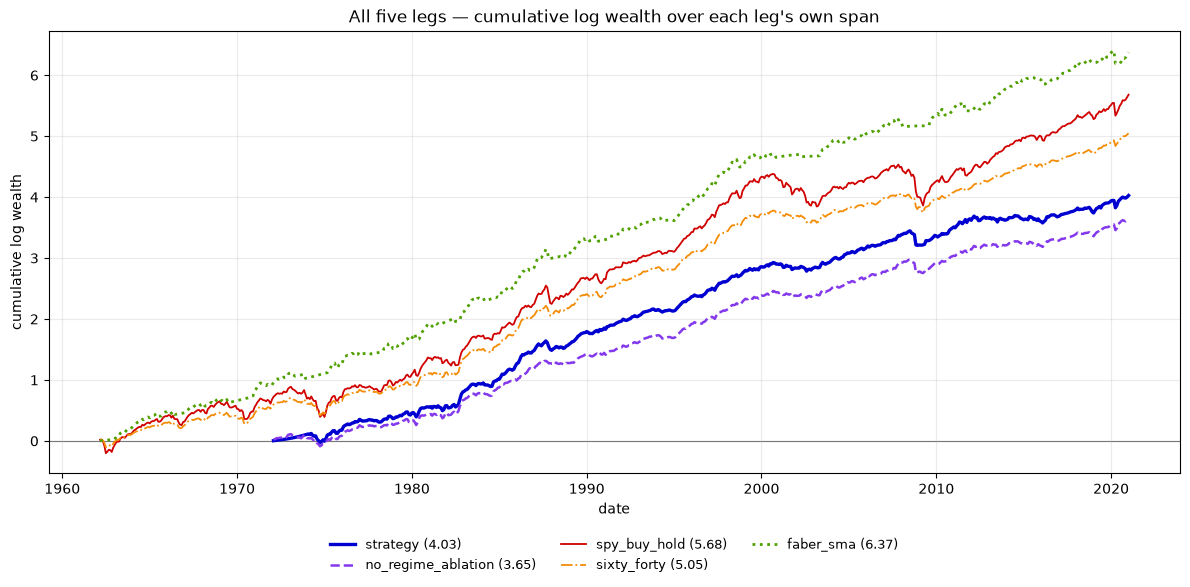

In [3]:
fig_curves = pbacktest.plot_equity_curves(
    curves, title="All five legs — cumulative log wealth over each leg's own span"
);

### Read the spans before reading the lines

The two ML legs and the three baselines **do not cover the same window**. The
walk-forward's first decision date arrives only after `backtest.min_train_months`
of warmup, while the price baselines start at the spine's first month. The printed
table above gives each leg's actual span; the chart draws each leg from its own
start, without renormalizing, because a silently aligned chart would misrepresent
the persisted KPI table — which also summarizes each leg over its own span.

So the next cell does the like-for-like version explicitly: every leg clipped to
the **intersection** of all five spans, which is the only window in which the five
terminal numbers are directly comparable. Both readings are shown; neither is
hidden.

common span: 1972-01-31 -> 2020-12-31

leg                    own span   common span
strategy                 4.0265        4.0265
no_regime_ablation       3.6472        3.6472
spy_buy_hold             5.6805        5.0008
sixty_forty              5.0471        4.4784
faber_sma                6.3726        5.4552


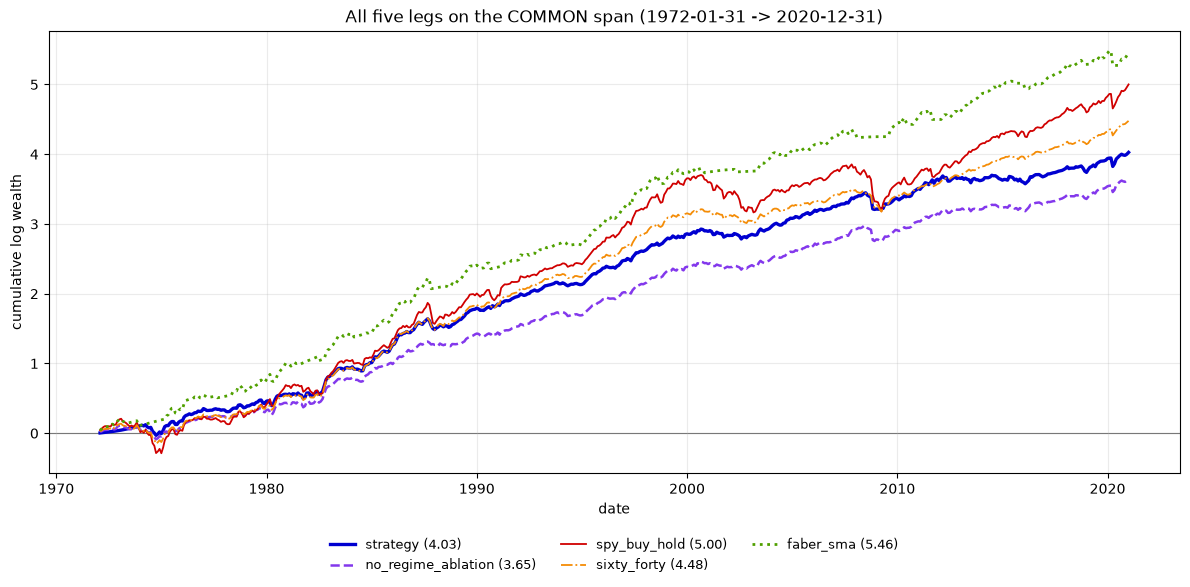

In [4]:
common_start = max(series.dropna().index.min() for series in curves.values())
common_end = min(series.dropna().index.max() for series in curves.values())
print(f"common span: {common_start.date()} -> {common_end.date()}")

common_curves = {name: series.loc[common_start:common_end] for name, series in curves.items()}

print()
print(f"{'leg':<20} {'own span':>10} {'common span':>13}")
for name, series in curves.items():
    own = float(np.log1p(series.dropna()).cumsum().iloc[-1])
    common = float(np.log1p(common_curves[name].dropna()).cumsum().iloc[-1])
    print(f"{name:<20} {own:>10.4f} {common:>13.4f}")

fig_curves_common = pbacktest.plot_equity_curves(
    common_curves,
    title=f"All five legs on the COMMON span ({common_start.date()} -> {common_end.date()})",
);

## The KPI table, under its plausibility bands

`pdrift.assert_kpi_table_plausible` runs **before** any KPI is rendered. It checks
every leg's terminal log wealth and max drawdown against two independent bounds: a
universal one (a log wealth whose magnitude exceeds 10 is not a return series; a
drawdown outside `[-1, 0]` is not a drawdown) and a *domain-informed per-leg* one
(a buy-and-hold leg that never lost 30% across 1973–74, 2000–02 and 2008–09 did not
happen; a blended 60/40 that never lost 10% did not happen either). It collects
every violation and raises once, so an impossible value stops this notebook here
rather than rendering silently into a chart that looks fine.

**Why this gate exists, concretely.** Two of the three recomputed baseline legs
were once recorded with arithmetically impossible values, and the phase was signed
off against them anyway — the incident is written up in
`.planning/UAT-AUDIT-2026-09-09.md`. Neither was a drift failure: the defect was
uniform across the whole span, so nothing drifted relative to itself. Only a
domain-informed per-leg band catches that class of error, which is why the band and
the drift statistic are both required and catch disjoint failure modes.

Those figures were corrected in September 2026 and this notebook does not reproduce
them. **Every number displayed below is read live from `backtest_kpi_table.parquet`
at render time** — nothing in this notebook hardcodes a KPI, historical or current.
If a leg regresses, the gate raises and the bars never appear.

In [5]:
kpi_table = pplot.load_report_artifact("backtest_kpi_table.parquet", rebuild_hint=REPORT_HINT)

# The gate: raises before anything is drawn if any leg is implausible.
verdict = pdrift.assert_kpi_table_plausible(kpi_table)
print(verdict.to_string(index=False))
print()
print(kpi_table.to_string(index=False))

               leg              metric     value universal_band   domain_band verdict
          strategy terminal_log_wealth  4.026505  abs(x) < 10.0  (-3.0, 12.0)    pass
          strategy        max_drawdown -0.212432    (-1.0, 0.0) (-0.8, -0.05)    pass
no_regime_ablation terminal_log_wealth  3.647238  abs(x) < 10.0  (-3.0, 12.0)    pass
no_regime_ablation        max_drawdown -0.198068    (-1.0, 0.0) (-0.8, -0.05)    pass
      spy_buy_hold terminal_log_wealth  5.680455  abs(x) < 10.0  (-3.0, 12.0)    pass
      spy_buy_hold        max_drawdown -0.489475    (-1.0, 0.0)  (-0.9, -0.3)    pass
       sixty_forty terminal_log_wealth  5.047073  abs(x) < 10.0  (-3.0, 12.0)    pass
       sixty_forty        max_drawdown -0.269625    (-1.0, 0.0)  (-0.8, -0.1)    pass
         faber_sma terminal_log_wealth  6.372592  abs(x) < 10.0  (-3.0, 12.0)    pass
         faber_sma        max_drawdown -0.189421    (-1.0, 0.0) (-0.5, -0.05)    pass

               leg  terminal_log_wealth  max_drawdown

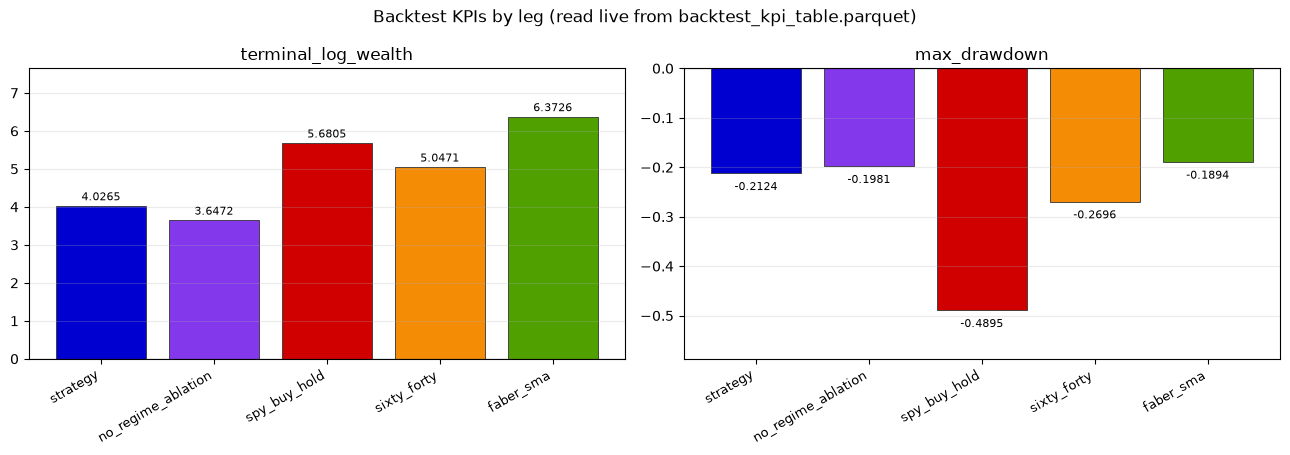

In [6]:
fig_kpi = pbacktest.plot_kpi_table_bars(kpi_table);

### The headline result — read it off the live ranking, not off prose

The next cell ranks the legs by terminal log wealth and evaluates the design §23.1
comparison (Faber versus the strategy on BOTH terminal wealth and max drawdown)
directly from the loaded table. Nothing about the ordering is asserted here in
words: it is derived at render time, so this page cannot go stale into a claim the
artifacts no longer support.

Whatever the ranking prints, read it without softening. This project's bar is
"beats buy-and-hold **net of avoided drawdowns**", and the two columns below are
exactly the two halves of that sentence — a leg that wins on drawdown while losing
on terminal wealth has not cleared the bar, it has traded one for the other.

In [7]:
ranked = kpi_table.sort_values("terminal_log_wealth", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", ranked.index + 1)
print("ranked by terminal log wealth (best first):")
print(ranked.to_string(index=False))

by_leg = kpi_table.set_index("leg")
strategy_w = float(by_leg.loc["strategy", "terminal_log_wealth"])
strategy_dd = float(by_leg.loc["strategy", "max_drawdown"])
baseline_legs = [leg for leg in by_leg.index if leg not in ("strategy", "no_regime_ablation")]

print()
print(f"strategy rank of {len(ranked)} legs on terminal log wealth: "
      f"{int(ranked.loc[ranked['leg'] == 'strategy', 'rank'].iloc[0])}")
beating = [leg for leg in baseline_legs
           if float(by_leg.loc[leg, "terminal_log_wealth"]) > strategy_w]
print(f"baseline legs beating the strategy on terminal log wealth: "
      f"{len(beating)} of {len(baseline_legs)} -> {beating}")

for leg in baseline_legs:
    w = float(by_leg.loc[leg, "terminal_log_wealth"])
    dd = float(by_leg.loc[leg, "max_drawdown"])
    both = (w > strategy_w) and (dd > strategy_dd)
    print(f"  {leg:<14} beats strategy on BOTH wealth and drawdown (design 23.1): {both}")

print()
print(f"strategy drawdown vs spy_buy_hold: {strategy_dd:+.4f} vs "
      f"{float(by_leg.loc['spy_buy_hold', 'max_drawdown']):+.4f}")

ranked by terminal log wealth (best first):
 rank                leg  terminal_log_wealth  max_drawdown
    1          faber_sma             6.372592     -0.189421
    2       spy_buy_hold             5.680455     -0.489475
    3        sixty_forty             5.047073     -0.269625
    4           strategy             4.026505     -0.212432
    5 no_regime_ablation             3.647238     -0.198068

strategy rank of 5 legs on terminal log wealth: 4
baseline legs beating the strategy on terminal log wealth: 3 of 3 -> ['spy_buy_hold', 'sixty_forty', 'faber_sma']
  spy_buy_hold   beats strategy on BOTH wealth and drawdown (design 23.1): False
  sixty_forty    beats strategy on BOTH wealth and drawdown (design 23.1): False
  faber_sma      beats strategy on BOTH wealth and drawdown (design 23.1): True

strategy drawdown vs spy_buy_hold: -0.2124 vs -0.4895


## Does the regime layer pay rent? (design §8.7)

The ablation is **not** a hand-rolled parallel implementation — it is the same
audited L1–L4 code path with `use_regime_tilt=False`. So the difference between the
two legs isolates the regime layer's contribution and nothing else.

`wealth_delta` is `strategy − no_regime_ablation` on terminal log wealth: positive
means the regime layer added terminal wealth. `dd_delta` is the same subtraction on
max drawdown, where both numbers are negative — so a **positive** `dd_delta` means
the strategy drew down *less* deeply than the ablation, and a negative one means it
drew down *more*.

Both are read live from the KPI table. Read the signs off the printed values below,
not off any expectation stated in prose.

In [8]:
delta = pbacktest.compute_ablation_delta(kpi_table)
for key, value in delta.items():
    print(f"{key}: {value:+.6f}")

print()
print(
    "wealth_delta > 0 => the regime layer added terminal wealth: "
    f"{delta['wealth_delta'] > 0}"
)
print(
    "dd_delta > 0 => the regime layer also reduced max drawdown: "
    f"{delta['dd_delta'] > 0}"
)

wealth_delta: +0.379267
dd_delta: -0.014364

wealth_delta > 0 => the regime layer added terminal wealth: True
dd_delta > 0 => the regime layer also reduced max drawdown: False


Whatever the two signs are above, note the scope of the claim they support. The
ablation delta says only whether the regime layer beat *its own regime-free twin*.
It says nothing about whether either leg beats the baseline gauntlet — the KPI bars
above already answered that, and the answer there was no. A regime layer can pay
rent relative to its ablation and still leave the whole strategy behind a 10-month
moving average.

## Calibration — does the nowcaster mean what it says?

The panel below is the "does calibration look sane at a glance" summary within this
evaluation dashboard. **P4 is the full diagnostic**: it renders the same persisted
`model_metrics_calibration.parquet` per class, with the per-class detail this
one-page view deliberately compresses.

The multiclass Brier score is gated first. Its no-skill floor for K classes is
`(K−1)/K²` — the score a model achieves by predicting the base rate and nothing
else. `assert_brier_plausible` returns that floor alongside a `beats_no_skill`
verdict; a Brier *above* the floor means the nowcaster cannot presently claim to
beat random guessing, which is an amber reading, not a green one, and it is
reported rather than smoothed over.

In [9]:
brier_df = pplot.load_report_artifact("model_metrics_brier.parquet", rebuild_hint=REPORT_HINT)
calib_df = pplot.load_report_artifact("model_metrics_calibration.parquet", rebuild_hint=REPORT_HINT)

brier_value = float(brier_df["brier"].iloc[0])
brier_verdict = pdrift.assert_brier_plausible(brier_value, n_classes=cfg["labeling"]["K"])
print(f"brier (read live): {brier_value:.6f}")
for key, value in brier_verdict.items():
    print(f"  {key}: {value}")

print()
print(f"calibration artifact: {calib_df.shape[0]} (class, bin) rows over "
      f"{calib_df['class_label'].nunique()} classes")

brier (read live): 0.208746
  value: 0.2087462934432449
  no_skill: 0.16
  beats_no_skill: False

calibration artifact: 21 (class, bin) rows over 5 classes


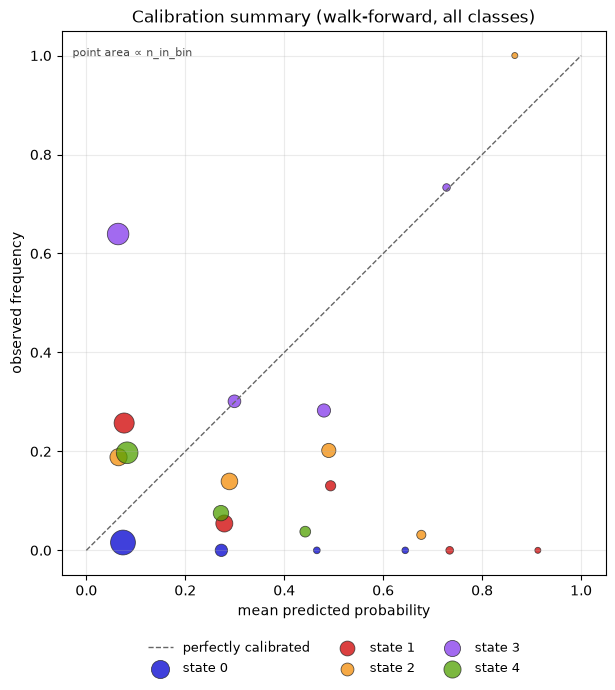

In [10]:
fig_calib = pbacktest.plot_calibration_summary(calib_df);

## The §5.4 sojourn / detection-lag headline — and why it is not a verdict

**Stated before any number is shown: the ratio and the detection lag below are
not interpretable pending audit item A13.** They are not a go/no-go signal, and no
plausibility band around them makes them one.

A13 is a third failure mode, distinct from the two the rest of this notebook
guards. Drift catches a distribution that moved; a plausibility band catches a
value that is physically impossible. A13 is a value that is **perfectly plausible
and computed against a mismatched target** — and neither of the other two checks
can see it.

Three independent reasons the gap below is not established to be a detection lag:

1. **Different feature sets.** The smoothed reference is fit on a fixed 9 columns
   across 695 months; the walk-forward's filtered path uses a per-window active set
   that changes seven times (4 → 6 → 8 → 9 → 10 → 12 → 13 columns).
2. **Different coverage.** 118 of 588 walk-forward steps (20.1%) are degraded and
   excluded, so the filtered path has only 470 rows and does not begin until
   1974-02 — about two years after the backtest's own 1972-01 start.
3. **Independent canonicalization.** P3 measures the two labelings disagreeing on
   **389 of 470 compared months — 82.8%**, and their confusion table shows *no
   diagonal structure at all* (the reference's 40.6%-occupancy state 3 scatters
   across all five filtered states). Two series that disagree 83% of the time are
   not tracking the same regimes, so their gap is not a delay between them.

And the number itself is a **median over a handful of resolved transitions** — the
resolved-of-total count is printed alongside the ratio below, and is drawn inside
the figure, for exactly that reason.

The caveat string printed first in the next cell is `core.A13_CAVEAT`, rendered
verbatim — the same single source P3 and P4 render, so the wording cannot drift
between notebooks.

In [11]:
# Single-source caveat string (core.A13_CAVEAT), printed BEFORE any number —
# identical in P3, P4 and here, so the wording cannot drift between notebooks.
print(pplot.A13_CAVEAT)
print()
print(
    "Coverage addendum (measured in plan 06-02): 118 of 588 walk-forward steps "
    "(20.1%) are degraded and excluded from per_step_metrics, so the filtered "
    "path has 470 rows and does not begin until 1974-02 — ~2 years after the "
    "backtest's 1972-01 start. The reference-vs-filtered comparison therefore "
    "covers ~80% of steps and is entirely absent early."
)

NOT INTERPRETABLE (audit item A13): this ratio compares a fixed-feature 'smoothed reference' labeling against the walk-forward's own per-window 'filtered' labeling, whose active feature set changes 7 times across the backtest (4 -> 6 -> 8 -> 9 -> 10 -> 12 -> 13 features). Their disagreement is therefore not purely detection delay, and no plausibility band around this number resolves that until A13 is settled.

Coverage addendum (measured in plan 06-02): 118 of 588 walk-forward steps (20.1%) are degraded and excluded from per_step_metrics, so the filtered path has 470 rows and does not begin until 1974-02 — ~2 years after the backtest's 1972-01 start. The reference-vs-filtered comparison therefore covers ~80% of steps and is entirely absent early.


In [12]:
full_sample_states = pplot.load_full_sample_states(rebuild_hint=REPORT_HINT)
filtered_probs_matrix = pplot.load_filtered_state_probs(rebuild_hint=REPORT_HINT)

print(
    f"smoothed reference: {len(full_sample_states)} months "
    f"{full_sample_states.index.min().date()} -> {full_sample_states.index.max().date()}"
)
print(
    f"filtered path:      {len(filtered_probs_matrix)} rows   "
    f"{filtered_probs_matrix.index.min().date()} -> {filtered_probs_matrix.index.max().date()}"
)

act_threshold = cfg.get("allocation", {}).get("hysteresis", {}).get("act_threshold", 0.70)
headline = compute_sojourn_lag_headline(
    full_sample_states, filtered_probs_matrix, act_threshold=act_threshold
)

print()
print(f"median_sojourn : {headline['median_sojourn']} months")
print(f"median_lag     : {headline['median_lag']} months")
print(f"ratio          : {headline['ratio']}   <- NOT INTERPRETABLE, see A13 above")
print(
    f"resolved       : n_resolved={headline['n_resolved']} of "
    f"n_transitions={headline['n_transitions']} transitions "
    f"(the ratio is a median over {headline['n_resolved']} observations)"
)
print(f"act_threshold  : {headline['act_threshold']}")

smoothed reference: 695 months 1963-02-28 -> 2020-12-31
filtered path:      470 rows   1974-02-28 -> 2020-12-31

median_sojourn : 97.0 months
median_lag     : 164.0 months
ratio          : 0.5914634146341463   <- NOT INTERPRETABLE, see A13 above
resolved       : n_resolved=4 of n_transitions=6 transitions (the ratio is a median over 4 observations)
act_threshold  : 0.7


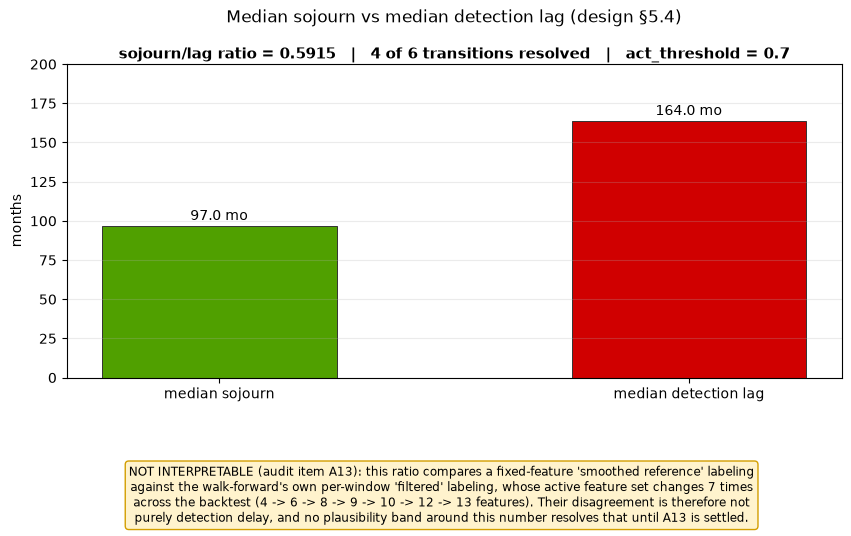

In [13]:
fig_headline = pbacktest.plot_sojourn_lag_headline(headline);

### No band around this number resolves A13

The figure above carries the caveat and the resolved-of-total count inside the
image itself, unconditionally — not behind a flag, not only when some threshold
trips — because a chart is the artifact most likely to be screenshotted away from
the paragraph that qualifies it.

To be explicit about what is *not* being claimed: **this notebook does not resolve
audit item A13, and nothing here should be read as resolving it.** The labeler's
fixed reference set and the walk-forward's per-window active sets are fit on
different columns over different spans, so the two series being compared are not
tracking identical targets. Until that is reconciled, the ratio measures the
mismatch as much as it measures any delay. Rendering it here makes A13
inspectable; settling it is a separate piece of work.

## Full-span drift — have the research assets moved since the fitted window?

Everything above is bounded at the 2020-12-31 holdout cutoff, because every
selection decision in this project is made on pre-2021 walk-forward evidence only.
This last panel is the deliberate, opt-in exception (D-06): it loads the **full
span** including post-2020 months and compares each core research series' recent
distribution against the pre-2021 window the models were actually fitted on.

The baseline is always that fitted window — never a rolling trailing window (D-09),
because a rolling baseline would slowly absorb a regime change and stop reporting
it. The table is ranked by absolute standardized mean shift whether or not anything
crosses the flag threshold, so the largest mover is always visible.

Looking is not deciding. If something here looks decision-changing, record it in
`.planning/POST-2020-OBSERVATIONS.md` (D-07) — that judgement is the operator's,
and an empty log is a valid state.

In [14]:
full_raw = pplot.load_full_span_checkpoint("monthly_raw", rebuild_hint=DATA_HINT)
full_research = build_core_research_series(full_raw, cfg)

print(
    f"full-span research series: {full_research.shape} "
    f"{full_research.index.min().date()} -> {full_research.index.max().date()}"
)

drift_df = pdrift.drift_report(
    full_research, list(full_research.columns), cutoff=DEFAULT_HOLDOUT_CUTOFF
)
print()
print(drift_df.to_string(index=False))
print()
print(f"columns flagged: {int(drift_df['flag'].sum())} of {len(drift_df)}")

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved price_col -> 'sp500' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved div_yield_col -> 'div_yield' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'long_duration_tr': resolved yield_col -> 'fred_gs10' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'gold': resolved source_col -> 'gold_spot' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'oil': resolved source_col -> 'wti_crude' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'cash': resolved yield_col -> 'fred_tb3ms' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:Built 5 core research series: ['cash', 'equities_tr', 'gold', 'long_duration_tr', 'oil']


full-span research series: (776, 5) 1962-01-31 -> 2026-08-31

          column  n_baseline  n_current  baseline_mean  baseline_std  current_mean  standardized_mean_shift  ks_statistic    ks_pvalue  pct_beyond_2sigma  flag
     equities_tr         708         68      47.186701     61.217745    426.303166                 6.192918      1.000000 3.151038e-99           1.000000  True
            gold         431         68     722.873527    481.821386   2552.255294                 3.796805      0.948956 1.079625e-64           0.970588  True
long_duration_tr         708         68      12.898512     12.788752     37.832892                 1.949712      0.882187 4.556131e-55           0.338235  True
            cash         708         68       7.238776      4.871208     15.442045                 1.684032      1.000000 3.151038e-99           0.088235  True
             oil         431         68      43.801508     28.753075     77.074853                 1.157210      0.688310 1.003535e-27    

## What this page delivered

ROADMAP criterion 5 names five elements. All five are above:

1. **Equity curves** — all five legs on one chart, twice: over each leg's own span
   and over the common span where the five terminal numbers are comparable.
2. **The baseline gauntlet** — SPY buy-and-hold, 60/40 and Faber, re-derived from
   the same splice math and cost convention the report layer uses, each KPI passed
   through `assert_kpi_table_plausible` before a single bar was drawn.
3. **The ablation delta** — design §8.7's "does the regime layer pay rent", both
   metrics, computed live from the KPI table.
4. **Calibration** — the same persisted artifact P4 details, gated on a Brier score
   checked against its no-skill floor.
5. **The sojourn / detection-lag headline** — with its resolved-of-total transition
   count printed beside the ratio and drawn inside the figure, and with
   `core.A13_CAVEAT` rendered verbatim.

**The A13 position, one final time:** the §5.4 ratio is not interpretable, this
notebook does not resolve A13, and no numeric band around that ratio would resolve
it. That is the honest state of the measurement, not a caveat added for form.

**P6 carries no sign-off cell and no per-run gate.** The one cold-start human
decision in this suite lives in P3 and nowhere else (D-15). Nothing in this
notebook writes a checkpoint, modifies a report artifact, appends a registry trial,
or fits a model — opening it is a read.